# Pareto Frontiers — Collective Algorithm Choice

**Question:** how much does the choice of collective algorithm move the decode Pareto frontier? Three configurations on the same hardware, same model:

1. **Worst-case SW** — pin every collective to *ring*. Maximum α-side cost on AR (`2(G-1)·α`); INC disabled. This is the do-nothing baseline an operator who never tunes the dispatcher would get.
2. **Optimized SW** — let `core/collective_algo_opt.optimize_collective_algorithms` pick the best SW algorithm per (phase × collective) by message-size-aware `min(enumerate_options(...))`. Still no INC. This is the headline benefit of the post-partition SW tuner: ring vs DBT vs hierarchical fall out automatically.
3. **INC** — let the optimizer pick INC where the fabric supports it (NVLS on the NVLink5 inner tier, Quantum SHARP on the IB outer tier — *AR/AG only*; A2A still uses SW pairwise since the sharp_class capability doesn't accelerate it). INC selection is prioritized over SW comparison: when available, it's used unconditionally.

**Setup:** GPT-1.8T MoE @ FP4 on a GB200 NVL576 cluster with NVLS + Quantum SHARP declared (`gb200.nvl576.hierarchical.inc.json`). All three sweeps share the same system spec — only the `TuningSpec` algorithm fields and `inc_enabled` flag change. This isolates the algorithm-choice effect from any topology / device differences.

**Why GPT-1.8T MoE on NVL576?** Same model + cluster as the other notebooks (`pareto_basic`, `pareto_vs_scale_up_tier`) so frontiers are directly comparable. With this model's divisibility (`TP | n_kv=16`, `EP | n_experts=16`, `PP | L=120`), individual collective groups stay ≤ 16 ranks — well within the 72-port NVLink5 inner tier — so the multi-tier hierarchical AR / AG branch from PR2 doesn't fire and the comparison is purely *single-tier ring vs DBT vs INC*.

## 1. Imports and spec loading

In [1]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.collective_algo_opt import optimize_collective_algorithms
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec

MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.nvl576.hierarchical.inc.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

print(f"Model:  {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  b={model.bytes_per_param}")
print(f"System: {system.name}  N={system.num_devices} GPUs")
tp_chain = system.get_tier_chain('TP')
for t in tp_chain:
    inc_str = f" inc={getattr(t, 'inc', 'none')}" if getattr(t, 'inc', 'none') != 'none' else ''
    print(f"  - tier {t.name:30s} ports={t.ports:3d} BW={t.bw_per_port_GBps:.0f} GB/s α={t.alpha_us:.2f} μs{inc_str}")

Model:  GPT-1.8T-MoE  L=120  H=20480  n_kv=16  b=0.5
System: gb200_nvl576_hierarchical_inc  N=576 GPUs
  - tier intra-rack-nvswitch            ports= 72 BW=900 GB/s α=0.50 μs inc=sharp_class
  - tier inter-rack-quantum-ib          ports=  8 BW=400 GB/s α=2.50 μs inc=sharp_class


## 2. Partition enumeration

Same divisibility constraints as `pareto_basic` and `pareto_vs_scale_up_tier`. `PP | L=120`, `TP | n_kv=16` and `H=20480`, `EP | n_experts=16`, `SP=1`.

In [2]:
PP_CHOICES = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 24, 30, 40, 60]
TP_CHOICES = [1, 2, 4, 8, 16]
EP_CHOICES = [1, 2, 4, 8, 16]
SP_CHOICES = [1, 2, 4, 8, 16, 32, 64]


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    out: list[PartitionSpec] = []
    for pp in PP_CHOICES:
        for tp in TP_CHOICES:
            for ep in EP_CHOICES:
                for sp in SP_CHOICES:
                    if pp * tp * ep * sp > num_devices:
                        continue
                    out.append(PartitionSpec(PP=pp, TP=tp, EP=ep, SP=sp))
    return out


partitions = enumerate_partitions(system.num_devices)
print(f"Valid partitions on {system.num_devices} GPUs: {len(partitions)}")

Valid partitions on 576 GPUs: 994


## 3. Sweep parameterized by collective-algorithm mode

One sweep function covers all three configs. The mode selects:

| Mode | tp/ep_algorithm_{decode,prefill} | inc_enabled |
|---|---|---|
| `worst` | `"ring"` | `False` |
| `sw_opt` | `"auto"` | `False` |
| `inc` | `"auto"` | `True` |

For `auto` modes, the optimizer is called per `(partition, B)` because message size depends on `B` and the optimizer's choice (ring vs tree at small M, INC where eligible) reflects that.

In [3]:
@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


def make_tuner(mode: str, base):
    t = deepcopy(base)
    if mode == "worst":
        t.tp_algorithm_decode = t.tp_algorithm_prefill = "ring"
        t.ep_algorithm_decode = t.ep_algorithm_prefill = "ring"
        t.inc_enabled = False
    elif mode == "sw_opt":
        t.tp_algorithm_decode = t.tp_algorithm_prefill = "auto"
        t.ep_algorithm_decode = t.ep_algorithm_prefill = "auto"
        t.inc_enabled = False
    elif mode == "inc":
        t.tp_algorithm_decode = t.tp_algorithm_prefill = "auto"
        t.ep_algorithm_decode = t.ep_algorithm_prefill = "auto"
        t.inc_enabled = True
    else:
        raise ValueError(f"unknown mode {mode!r}")
    return t


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep(mode: str) -> list[Point]:
    base = make_tuner(mode, tuner_base)
    pts: list[Point] = []
    for partition in partitions:
        try:
            mem = compute_memory(model, system, partition, base)
        except Exception:
            continue
        paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
        kv = compute_kv_paging(model, system, partition, base, mem, paging)
        b_max = int(kv.max_sequences)
        if b_max < 1:
            continue
        for B in log_spaced_batch_sizes(b_max):
            tuner = deepcopy(base)
            tuner.B_decode = B
            # Resolve `auto` per (partition, B) since message size depends on B.
            if mode != "worst":
                tuner = optimize_collective_algorithms(model, partition, system, tuner)
            try:
                r = InferenceCalculator(model, system, partition, tuner).run()
            except Exception:
                continue
            if r.latency.TPOT <= 0:
                continue
            pts.append(Point(
                partition=partition, B=B,
                tput_per_gpu=r.latency.TTPS / system.num_devices,
                interactivity=1.0 / r.latency.TPOT,
                TPOT_ms=r.latency.TPOT * 1e3,
            ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier


MODES = ["worst", "sw_opt", "inc"]
all_points = {m: sweep(m) for m in MODES}
frontiers = {m: pareto_frontier(all_points[m]) for m in MODES}

for m in MODES:
    fr = frontiers[m]
    print(f"  {m:8s}  cloud={len(all_points[m]):4d}  frontier={len(fr):3d}")

  worst     cloud=35643  frontier= 43
  sw_opt    cloud=35643  frontier= 43
  inc       cloud=35643  frontier= 43


## 4. Plot — three frontiers overlaid

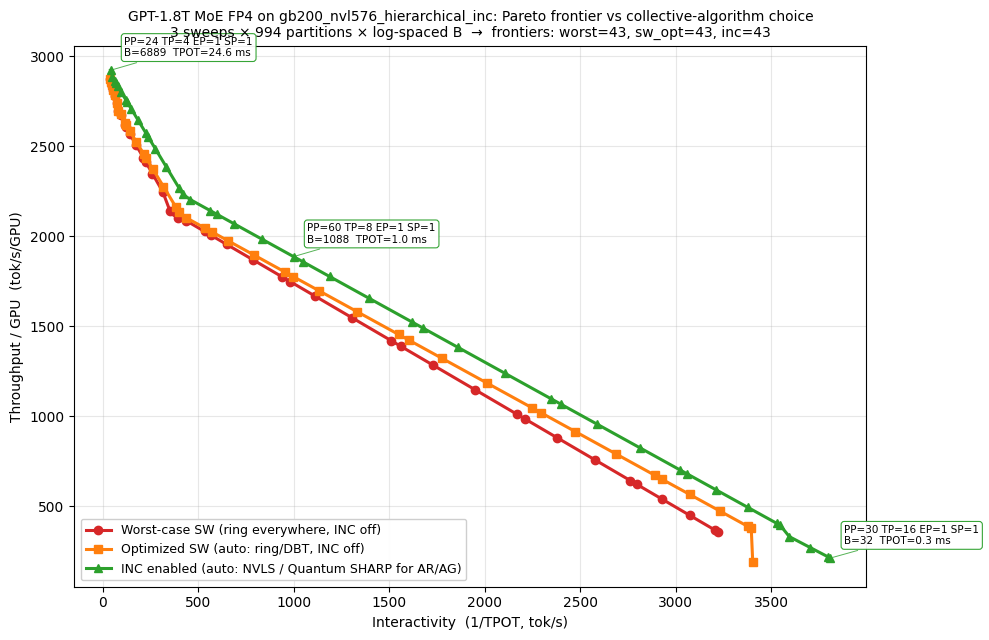

In [4]:
fig, ax = plt.subplots(figsize=(10, 6.5))

STYLES = {
    "worst":  dict(color="tab:red",    lw=2.2, ms=6, marker="o", label="Worst-case SW (ring everywhere, INC off)"),
    "sw_opt": dict(color="tab:orange", lw=2.2, ms=6, marker="s", label="Optimized SW (auto: ring/DBT, INC off)"),
    "inc":    dict(color="tab:green",  lw=2.2, ms=6, marker="^", label="INC enabled (auto: NVLS / Quantum SHARP for AR/AG)"),
}

for m in MODES:
    fr = frontiers[m]
    if not fr:
        continue
    xs = [p.interactivity for p in fr]
    ys = [p.tput_per_gpu for p in fr]
    ax.plot(xs, ys, "-", **STYLES[m])

# Annotate corners on the INC frontier (the headline curve).
fr_inc = frontiers["inc"]
if len(fr_inc) >= 3:
    idxs = [0, len(fr_inc) // 2, len(fr_inc) - 1]
    for i in idxs:
        p = fr_inc[i]
        ax.annotate(
            f"{p.part_label}\nB={p.B}  TPOT={p.TPOT_ms:.1f} ms",
            xy=(p.interactivity, p.tput_per_gpu),
            xytext=(10, 10), textcoords="offset points",
            fontsize=7.5, ha="left", color="black",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="tab:green", alpha=0.95, lw=0.8),
            arrowprops=dict(arrowstyle="-", color="tab:green", lw=0.7, alpha=0.8),
        )

ax.set_xscale("linear")
ax.set_yscale("linear")
ax.set_xlabel("Interactivity  (1/TPOT, tok/s)")
ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
ax.set_title(
    f"GPT-1.8T MoE FP4 on {system.name}: Pareto frontier vs collective-algorithm choice\n"
    f"3 sweeps × {len(partitions)} partitions × log-spaced B  →  "
    f"frontiers: worst={len(frontiers['worst'])}, sw_opt={len(frontiers['sw_opt'])}, "
    f"inc={len(frontiers['inc'])}",
    fontsize=10,
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
fig.tight_layout()
fig.savefig("assets/pareto_collective_algorithms.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Per-corner comparison table

For a few representative corners (lowest-throughput high-interactivity, mid-frontier, highest-throughput low-interactivity), what does each mode pick and how does TPOT compare?

In [5]:
def at_interactivity(fr, target_interact):
    if not fr:
        return None
    return min(fr, key=lambda p: abs(math.log(p.interactivity / target_interact)))


if frontiers["inc"]:
    inc_xs = [p.interactivity for p in frontiers["inc"]]
    targets = [
        ("high-interactivity", max(inc_xs)),
        ("mid frontier",       (min(inc_xs) * max(inc_xs)) ** 0.5),
        ("high-throughput",    min(inc_xs)),
    ]
    print(f"{'corner':22s} {'mode':10s} {'partition':24s} {'B':>5s} {'TPOT (ms)':>10s} {'tput/GPU':>10s}")
    print("-" * 86)
    for label, tgt in targets:
        for m in MODES:
            p = at_interactivity(frontiers[m], tgt)
            if p is None:
                continue
            print(f"{label:22s} {m:10s} {p.part_label:24s} {p.B:>5d} {p.TPOT_ms:>10.2f} {p.tput_per_gpu:>10.2f}")
        print()

corner                 mode       partition                    B  TPOT (ms)   tput/GPU
--------------------------------------------------------------------------------------
high-interactivity     worst      PP=60 TP=8 EP=1 SP=1        64       0.31     357.76
high-interactivity     sw_opt     PP=30 TP=16 EP=1 SP=1       32       0.29     189.03
high-interactivity     inc        PP=30 TP=16 EP=1 SP=1       32       0.26     211.60

mid frontier           worst      PP=24 TP=8 EP=1 SP=1      1024       2.54    2098.97
mid frontier           sw_opt     PP=24 TP=8 EP=1 SP=1      1024       2.50    2132.54
mid frontier           inc        PP=24 TP=8 EP=1 SP=1      1089       2.50    2267.36

high-throughput        worst      PP=24 TP=4 EP=1 SP=1      6889      24.97    2873.36
high-throughput        sw_opt     PP=24 TP=4 EP=1 SP=1      6889      24.96    2874.51
high-throughput        inc        PP=24 TP=4 EP=1 SP=1      6889      24.56    2922.26



## 6. Takeaways

- **Worst-case → optimized SW**: pinning every collective to ring inflates the α-term proportional to `2(G-1)` instead of `2·log₂G` for DBT. With `G ≤ 16` on this model (TP and EP capped at 16), that's a 2× α-term penalty before any BW cost is paid. The shift from red to orange shows what the SW optimizer recovers automatically.
- **Optimized SW → INC**: the green curve is the upper bound on what's achievable on this fabric *without* changing partition or hardware. AR's `n_α` collapses from `2·log₂G` to ~2 (the switch-cut-through round trip) and `BW_eff` doubles for AR (switch ALU + multicast crossbar fuse the two halves of the dual-touch pattern). The shift from orange to green is the value of the NVLS / Quantum SHARP capability on this rack.
- **The optimizer respects orthogonality**: turn `inc_enabled=False` and the optimizer falls back to SW per-cell (orange curve). Turn `inc_enabled=True` and it short-circuits to INC for any op the fabric accelerates (green curve). EP A2A is still on the SW path in both cases — sharp_class doesn't accelerate A2A; HW A2A would need a Tomahawk-Ultra-class tier (`inc=hw_a2a`) which this system does not declare.
- **The frontier shifts are model + cluster sensitive**: this model's small group sizes (≤ 16) keep all collectives single-tier. On a model with `EP > 72` (e.g. DeepSeek-R1 with `n_experts=256` running EP=128 or 256), the multi-tier hierarchical AR / AG branch fires and the gap between `worst` and `sw_opt` widens further — the optimizer additionally swaps in the hierarchical RS → sub-AR → AG composition with payload telescoping. See `pareto_vs_scale_up_tier.ipynb` for the multi-tier case study.